In [ ]:
!nvidia-smi
import torch
print(f"\nCUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    total = torch.cuda.get_device_properties(0).total_memory/1e9
    print(f"VRAM: {total:.1f} GB")
    print("✅ GPU OK — tiếp tục Cell 2!")
else:
    print("❌ Không có GPU! Vào Runtime → Change runtime type → T4 GPU")

Wed Apr 29 01:52:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install transformers==4.35.0 -q
!pip install torch scikit-learn pandas numpy matplotlib seaborn -q
print("✅ Cài xong — tiếp tục Cell 3!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.1/123.1 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 127.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.0/295.0 kB 33.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 4.0.0 requires huggingface-hub>=0.24.0, but you have huggingface-hub 0.17.3 which is incompatible.
diffusers 0.37.1 requires huggingface-hub<2.0,>=0.34.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.4.1 requires huggingface-hub>=0.23.0, but you have huggingface-hub 0.17.3 which is incompatible.
sentence-transformers 5.4.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.35.0 which is incompatible.
gradio-client 1.14.0 requires huggingface

In [ ]:
import os, gc, re, time, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    RobertaTokenizer, RobertaForSequenceClassification,
    DistilBertTokenizer, DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.metrics import (
    accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix
)
warnings.filterwarnings('ignore')
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs('/content/outputs', exist_ok=True)
os.makedirs('/content/models',  exist_ok=True)

total = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✅ Import xong!")
print(f"   Device : {device}")
print(f"   VRAM   : {total:.1f} GB  ← phải ~14-15 GB")
print("Tiếp tục Cell 4!")

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


✅ Import xong!
   Device : cuda
   VRAM   : 15.6 GB  ← phải ~14-15 GB
Tiếp tục Cell 4!


In [ ]:
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
df  = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

def preprocess_text(text):
    """Algorithm 1 — bài báo ExplainableDetector"""
    text = str(text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    text = text.replace('\r', ' ').strip()
    words, seen = text.split(), []
    for w in words:
        if w not in seen:
            seen.append(w)
    return ' '.join(seen)

df['message_clean'] = df['message'].apply(preprocess_text)
df['label_num']     = df['label'].map({'ham': 0, 'spam': 1})

print(f"✅ Dataset loaded!")
print(f"   Tổng : {len(df)} mẫu")
print(f"   Ham  : {(df['label_num']==0).sum()}")
print(f"   Spam : {(df['label_num']==1).sum()}")
print("Tiếp tục Cell 5!")

✅ Dataset loaded!
   Tổng : 5572 mẫu
   Ham  : 4825
   Spam : 747
Tiếp tục Cell 5!


In [ ]:
# ── IMBALANCED (5574 mẫu gốc) ──
X_train_imb, X_test_imb, y_train_imb, y_test_imb = train_test_split(
    df['message_clean'], df['label_num'],
    test_size=0.2, random_state=42, stratify=df['label_num']
)

# ── BALANCED (oversampling spam lên 4825) ──
df_ham       = df[df['label_num']==0].copy()
df_spam      = df[df['label_num']==1].copy()
df_spam_over = resample(df_spam, replace=True,
                        n_samples=len(df_ham), random_state=42)
df_bal = pd.concat([df_ham, df_spam_over]).sample(
    frac=1, random_state=42).reset_index(drop=True)

X_train_bal, X_test_bal, y_train_bal, y_test_bal = train_test_split(
    df_bal['message_clean'], df_bal['label_num'],
    test_size=0.2, random_state=42, stratify=df_bal['label_num']
)

print("✅ Split xong!")
print(f"   Imbalanced — Train: {len(X_train_imb)}, Test: {len(X_test_imb)}")
print(f"   Balanced   — Train: {len(X_train_bal)}, Test: {len(X_test_bal)}")
print("Tiếp tục Cell 6!")

✅ Split xong!
   Imbalanced — Train: 4457, Test: 1115
   Balanced   — Train: 7720, Test: 1930
Tiếp tục Cell 6!


In [ ]:
class SpamDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = list(texts)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return (
            enc['input_ids'].squeeze(0),
            enc['attention_mask'].squeeze(0),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

print("✅ SpamDataset class định nghĩa xong! Tiếp tục Cell 7!")

✅ SpamDataset class định nghĩa xong! Tiếp tục Cell 7!


In [ ]:
def train_model(model_name, tokenizer_class, model_class,
                X_train, X_test, y_train, y_test, dataset_type,
                epochs=5, micro_batch=4, accum_steps=8,
                test_batch=16, lr=2e-5, max_len=128):
    """
    Hyperparameters khớp Table 1 bài báo:
      effective batch = micro_batch × accum_steps = 4 × 8 = 32
      optimizer = AdamW, lr = 2e-5, epochs = 5
    max_len=128 thay vì 512: SMS ngắn ~40 tokens, tiết kiệm VRAM 16×
    """
    torch.cuda.empty_cache()
    gc.collect()

    free = (torch.cuda.get_device_properties(0).total_memory
            - torch.cuda.memory_allocated(0)) / 1e9
    print(f"\n{'='*58}")
    print(f"  MODEL      : {model_name}")
    print(f"  DATASET    : {dataset_type}")
    print(f"  VRAM free  : {free:.1f} GB")
    print(f"  Batch size : {micro_batch}×{accum_steps} = {micro_batch*accum_steps} (effective)")
    print(f"  LR         : {lr} | Epochs: {epochs} | max_len: {max_len}")
    print(f"{'='*58}")

    # Load tokenizer + model
    print("⏳ Loading model...")
    tokenizer = tokenizer_class.from_pretrained(model_name)
    model     = model_class.from_pretrained(model_name, num_labels=2)
    model     = model.to(device)

    used = torch.cuda.memory_allocated(0) / 1e9
    print(f"   Model loaded — VRAM used: {used:.1f} GB")

    # DataLoader
    train_ds = SpamDataset(X_train, y_train, tokenizer, max_len)
    test_ds  = SpamDataset(X_test,  y_test,  tokenizer, max_len)
    train_dl = DataLoader(train_ds, batch_size=micro_batch,
                          shuffle=True,  num_workers=2, pin_memory=True)
    test_dl  = DataLoader(test_ds,  batch_size=test_batch,
                          shuffle=False, num_workers=2, pin_memory=True)

    # Optimizer + Scheduler (AdamW — bài báo)
    optimizer   = AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = (len(train_dl) // accum_steps) * epochs
    scheduler   = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    history = {'train_loss':[], 'train_acc':[], 'test_loss':[], 'test_acc':[]}

    print(f"\n{'Epoch':>6} {'TrLoss':>9} {'TrAcc%':>8} {'TeLoss':>9} {'TeAcc%':>8} {'Time':>6}")
    print("─"*52)

    for epoch in range(1, epochs+1):
        t0 = time.time()

        # ── TRAIN ──
        model.train()
        tr_loss, correct, total_n = 0.0, 0, 0
        optimizer.zero_grad()

        for step, (ids, mask, lbls) in enumerate(train_dl):
            ids  = ids.to(device)
            mask = mask.to(device)
            lbls = lbls.to(device)

            out  = model(input_ids=ids, attention_mask=mask, labels=lbls)
            loss = out.loss / accum_steps
            loss.backward()

            tr_loss  += out.loss.item()
            correct  += (out.logits.argmax(1) == lbls).sum().item()
            total_n  += len(lbls)

            if (step + 1) % accum_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
                optimizer.zero_grad()

            # Giải phóng tensor ngay
            del ids, mask, lbls, out, loss
            if step % 30 == 0:
                torch.cuda.empty_cache()

        tr_loss /= len(train_dl)
        tr_acc   = correct / total_n * 100

        # ── EVAL ──
        model.eval()
        te_loss, te_correct, te_total = 0.0, 0, 0
        all_preds, all_labels_list = [], []

        with torch.no_grad():
            for ids, mask, lbls in test_dl:
                ids  = ids.to(device)
                mask = mask.to(device)
                lbls = lbls.to(device)

                out   = model(input_ids=ids, attention_mask=mask, labels=lbls)
                preds = out.logits.argmax(1)

                te_loss    += out.loss.item()
                te_correct += (preds == lbls).sum().item()
                te_total   += len(lbls)
                all_preds.extend(preds.cpu().numpy())
                all_labels_list.extend(lbls.cpu().numpy())

                del ids, mask, lbls, out, preds

        te_loss /= len(test_dl)
        te_acc   = te_correct / te_total * 100

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['test_loss'].append(te_loss)
        history['test_acc'].append(te_acc)

        elapsed = time.time() - t0
        print(f"{epoch:>6} {tr_loss:>9.4f} {tr_acc:>7.2f}% "
              f"{te_loss:>9.4f} {te_acc:>7.2f}%  {elapsed:>5.0f}s")

        torch.cuda.empty_cache()

    # Lưu model
    fname = f"/content/models/{model_name.replace('/','-')}_{dataset_type}.pt"
    torch.save(model.state_dict(), fname)
    print(f"\n✅ Xong! Saved → {fname}")
    print(f"   Train Acc: {history['train_acc'][-1]:.2f}%")
    print(f"   Test  Acc: {history['test_acc'][-1]:.2f}%")

    return model, tokenizer, history, all_preds, all_labels_list

print("✅ train_model() định nghĩa xong! Tiếp tục Cell 8!")

✅ train_model() định nghĩa xong! Tiếp tục Cell 8!


In [ ]:
def plot_history(history, model_name, dataset_type, save_path):
    """Vẽ Figure 6 / Figure 8 trong bài báo"""
    epochs = range(1, len(history['train_acc']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs, history['train_acc'], 'g-o',
                 label='Training Accuracy', linewidth=2, markersize=7)
    axes[0].plot(epochs, history['test_acc'],  'r-o',
                 label='Test Accuracy', linewidth=2, markersize=7)
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0].set_title('Training & Testing Accuracy', fontsize=12, fontweight='bold')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(list(epochs))

    # Loss
    axes[1].plot(epochs, history['train_loss'], 'g-o',
                 label='Training Loss', linewidth=2, markersize=7)
    axes[1].plot(epochs, history['test_loss'],  'r-o',
                 label='Test Loss', linewidth=2, markersize=7)
    axes[1].set_xlabel('Epochs', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Training & Testing Loss', fontsize=12, fontweight='bold')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(list(epochs))

    plt.suptitle(f'{model_name} — {dataset_type} Data',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Saved: {save_path}")


def print_metrics(preds, labels, model_name, dataset_type):
    """In Table 2/3/5/6 theo bài báo"""
    cm  = confusion_matrix(labels, preds)
    acc = accuracy_score(labels, preds) * 100

    print(f"\n{'='*58}")
    print(f"  {model_name} — {dataset_type}")
    print(f"{'='*58}")
    print(f"  Confusion Matrix:")
    print(f"                Pred ham   Pred spam")
    print(f"  Actual ham  :   {cm[0,0]:>6}      {cm[0,1]:>6}")
    print(f"  Actual spam :   {cm[1,0]:>6}      {cm[1,1]:>6}")
    print(f"\n  Overall Accuracy: {acc:.2f}%")
    print(f"\n  {'Class':<8} {'Precision':>10} {'Recall':>8} {'F1':>8}")
    print(f"  {'-'*38}")
    for cls, lbl in [('ham', 0), ('spam', 1)]:
        p = precision_score(labels, preds, pos_label=lbl, average='binary', zero_division=0)
        r = recall_score(labels, preds, pos_label=lbl, average='binary', zero_division=0)
        f = f1_score(labels, preds, pos_label=lbl, average='binary', zero_division=0)
        print(f"  {cls:<8} {p:>10.2f} {r:>8.2f} {f:>8.2f}")
    print(f"{'='*58}")
    return cm, acc

print("✅ plot_history() và print_metrics() sẵn sàng! Tiếp tục Cell 9!")

✅ plot_history() và print_metrics() sẵn sàng! Tiếp tục Cell 9!



  MODEL      : distilbert-base-uncased
  DATASET    : Imbalanced
  VRAM free  : 15.6 GB
  Batch size : 4×8 = 32 (effective)
  LR         : 2e-05 | Epochs: 5 | max_len: 128
⏳ Loading model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Model loaded — VRAM used: 0.3 GB

 Epoch    TrLoss   TrAcc%    TeLoss   TeAcc%   Time
────────────────────────────────────────────────────
     1    0.2157   89.75%    0.0439   98.74%     57s
     2    0.0328   99.10%    0.0473   98.92%     61s
     3    0.0142   99.60%    0.0456   99.01%     60s
     4    0.0082   99.82%    0.0450   98.65%     59s
     5    0.0039   99.87%    0.0466   98.65%     60s

✅ Xong! Saved → /content/models/distilbert-base-uncased_Imbalanced.pt
   Train Acc: 99.87%
   Test  Acc: 98.65%


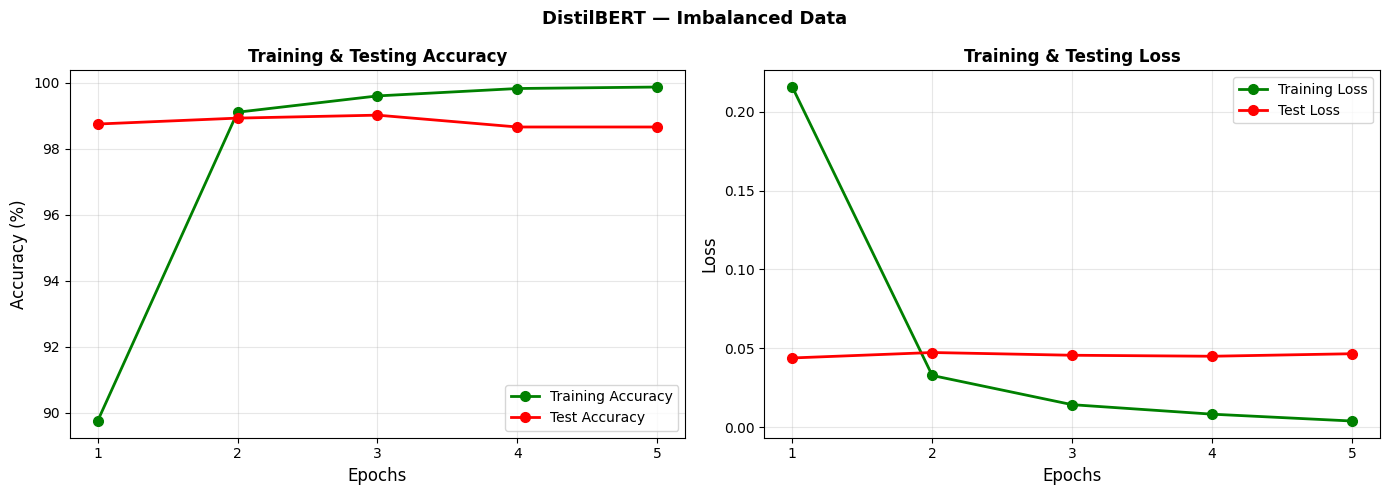

✅ Saved: /content/outputs/fig6a_distilbert_imbalanced.png

  DistilBERT — Imbalanced
  Confusion Matrix:
                Pred ham   Pred spam
  Actual ham  :      960           6
  Actual spam :        9         140

  Overall Accuracy: 98.65%

  Class     Precision   Recall       F1
  --------------------------------------
  ham            0.99     0.99     0.99
  spam           0.96     0.94     0.95

⏭️ Tiếp tục Cell 10!


In [ ]:
# Đảm bảo VRAM sạch
torch.cuda.empty_cache(); gc.collect()

distilbert_imb_model, distilbert_imb_tok, \
distilbert_imb_hist, distilbert_imb_preds, \
distilbert_imb_labels = train_model(
    model_name      = 'distilbert-base-uncased',
    tokenizer_class = DistilBertTokenizer,
    model_class     = DistilBertForSequenceClassification,
    X_train = X_train_imb, X_test = X_test_imb,
    y_train = y_train_imb, y_test = y_test_imb,
    dataset_type = 'Imbalanced'
)

plot_history(distilbert_imb_hist, 'DistilBERT', 'Imbalanced',
             '/content/outputs/fig6a_distilbert_imbalanced.png')

distilbert_imb_cm, distilbert_imb_acc = print_metrics(
    distilbert_imb_preds, distilbert_imb_labels,
    'DistilBERT', 'Imbalanced'
)
print("\n⏭️ Tiếp tục Cell 10!")

VRAM free sau khi xóa DistilBERT: 15.6 GB  ← cần ≥ 10 GB

  MODEL      : roberta-base
  DATASET    : Imbalanced
  VRAM free  : 15.6 GB
  Batch size : 4×8 = 32 (effective)
  LR         : 2e-05 | Epochs: 5 | max_len: 128
⏳ Loading model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Model loaded — VRAM used: 0.5 GB

 Epoch    TrLoss   TrAcc%    TeLoss   TeAcc%   Time
────────────────────────────────────────────────────
     1    0.2037   94.32%    0.0480   98.39%    119s
     2    0.0325   99.24%    0.0406   99.19%    118s
     3    0.0123   99.73%    0.0470   99.28%    118s
     4    0.0045   99.87%    0.0480   99.37%    118s
     5    0.0002  100.00%    0.0495   99.37%    121s

✅ Xong! Saved → /content/models/roberta-base_Imbalanced.pt
   Train Acc: 100.00%
   Test  Acc: 99.37%


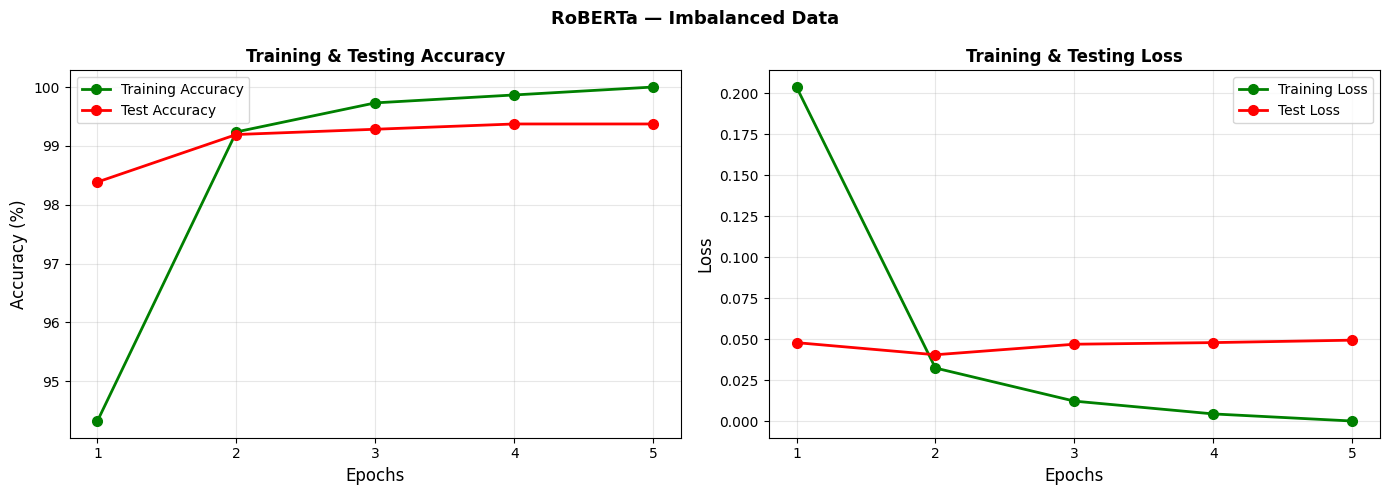

✅ Saved: /content/outputs/fig6b_roberta_imbalanced.png

  RoBERTa — Imbalanced
  Confusion Matrix:
                Pred ham   Pred spam
  Actual ham  :      965           1
  Actual spam :        6         143

  Overall Accuracy: 99.37%

  Class     Precision   Recall       F1
  --------------------------------------
  ham            0.99     1.00     1.00
  spam           0.99     0.96     0.98

⏭️ Tiếp tục Cell 11!


In [ ]:
# ⚠️ BẮT BUỘC: Xóa DistilBERT khỏi GPU trước
del distilbert_imb_model
torch.cuda.empty_cache(); gc.collect()

free = (torch.cuda.get_device_properties(0).total_memory
        - torch.cuda.memory_allocated(0)) / 1e9
print(f"VRAM free sau khi xóa DistilBERT: {free:.1f} GB  ← cần ≥ 10 GB")

roberta_imb_model, roberta_imb_tok, \
roberta_imb_hist, roberta_imb_preds, \
roberta_imb_labels = train_model(
    model_name      = 'roberta-base',
    tokenizer_class = RobertaTokenizer,
    model_class     = RobertaForSequenceClassification,
    X_train = X_train_imb, X_test = X_test_imb,
    y_train = y_train_imb, y_test = y_test_imb,
    dataset_type = 'Imbalanced'
)

plot_history(roberta_imb_hist, 'RoBERTa', 'Imbalanced',
             '/content/outputs/fig6b_roberta_imbalanced.png')

roberta_imb_cm, roberta_imb_acc = print_metrics(
    roberta_imb_preds, roberta_imb_labels,
    'RoBERTa', 'Imbalanced'
)
print("\n⏭️ Tiếp tục Cell 11!")

VRAM free: 15.6 GB  ← cần ≥ 10 GB

  MODEL      : distilbert-base-uncased
  DATASET    : Balanced
  VRAM free  : 15.6 GB
  Batch size : 4×8 = 32 (effective)
  LR         : 2e-05 | Epochs: 5 | max_len: 128
⏳ Loading model...


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['pre_classifier.weight', 'pre_classifier.bias', 'classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Model loaded — VRAM used: 0.3 GB

 Epoch    TrLoss   TrAcc%    TeLoss   TeAcc%   Time
────────────────────────────────────────────────────
     1    0.1958   91.99%    0.0362   98.96%    106s
     2    0.0130   99.70%    0.0059   99.74%    103s
     3    0.0026   99.95%    0.0009  100.00%    104s
     4    0.0007   99.99%    0.0020   99.95%    104s
     5    0.0004  100.00%    0.0022   99.95%    106s

✅ Xong! Saved → /content/models/distilbert-base-uncased_Balanced.pt
   Train Acc: 100.00%
   Test  Acc: 99.95%


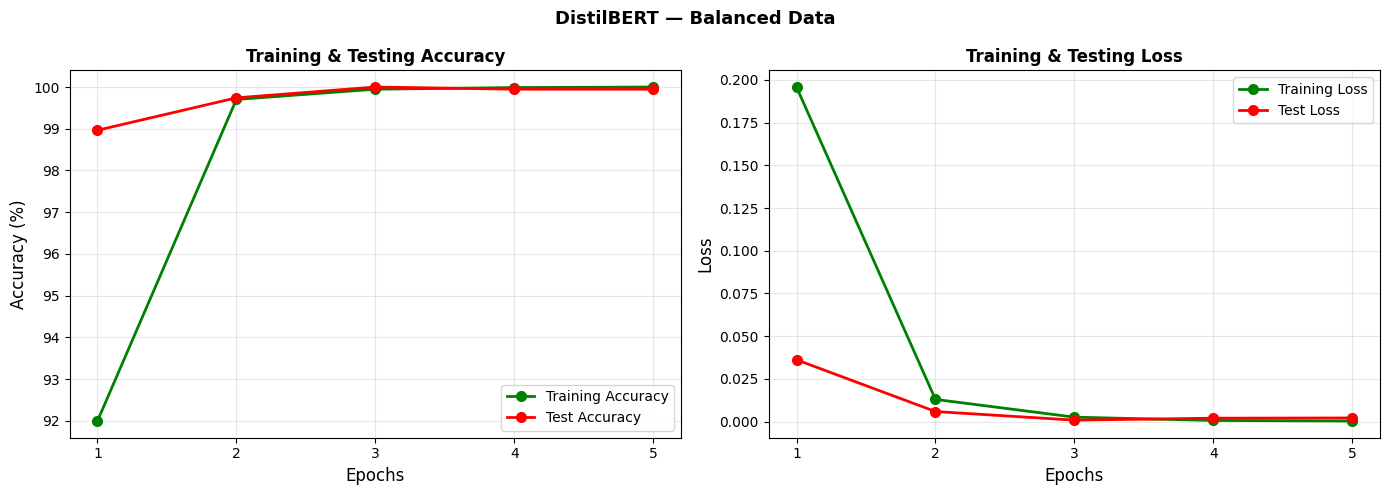

✅ Saved: /content/outputs/fig8a_distilbert_balanced.png

  DistilBERT — Balanced
  Confusion Matrix:
                Pred ham   Pred spam
  Actual ham  :      964           1
  Actual spam :        0         965

  Overall Accuracy: 99.95%

  Class     Precision   Recall       F1
  --------------------------------------
  ham            1.00     1.00     1.00
  spam           1.00     1.00     1.00

⏭️ Tiếp tục Cell 12!


In [ ]:
# ⚠️ BẮT BUỘC: Xóa RoBERTa trước
del roberta_imb_model
torch.cuda.empty_cache(); gc.collect()

free = (torch.cuda.get_device_properties(0).total_memory
        - torch.cuda.memory_allocated(0)) / 1e9
print(f"VRAM free: {free:.1f} GB  ← cần ≥ 10 GB")

distilbert_bal_model, distilbert_bal_tok, \
distilbert_bal_hist, distilbert_bal_preds, \
distilbert_bal_labels = train_model(
    model_name      = 'distilbert-base-uncased',
    tokenizer_class = DistilBertTokenizer,
    model_class     = DistilBertForSequenceClassification,
    X_train = X_train_bal, X_test = X_test_bal,
    y_train = y_train_bal, y_test = y_test_bal,
    dataset_type = 'Balanced'
)

plot_history(distilbert_bal_hist, 'DistilBERT', 'Balanced',
             '/content/outputs/fig8a_distilbert_balanced.png')

distilbert_bal_cm, distilbert_bal_acc = print_metrics(
    distilbert_bal_preds, distilbert_bal_labels,
    'DistilBERT', 'Balanced'
)
print("\n⏭️ Tiếp tục Cell 12!")

VRAM free: 15.6 GB  ← cần ≥ 10 GB

  MODEL      : roberta-base
  DATASET    : Balanced
  VRAM free  : 15.6 GB
  Batch size : 4×8 = 32 (effective)
  LR         : 2e-05 | Epochs: 5 | max_len: 128
⏳ Loading model...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.out_proj.weight', 'classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


   Model loaded — VRAM used: 0.5 GB

 Epoch    TrLoss   TrAcc%    TeLoss   TeAcc%   Time
────────────────────────────────────────────────────
     1    0.1800   90.22%    0.0145   99.74%    206s
     2    0.0113   99.72%    0.0162   99.79%    206s
     3    0.0020   99.96%    0.0097   99.84%    205s
     4    0.0002   99.99%    0.0146   99.79%    205s
     5    0.0001  100.00%    0.0146   99.79%    205s

✅ Xong! Saved → /content/models/roberta-base_Balanced.pt
   Train Acc: 100.00%
   Test  Acc: 99.79%


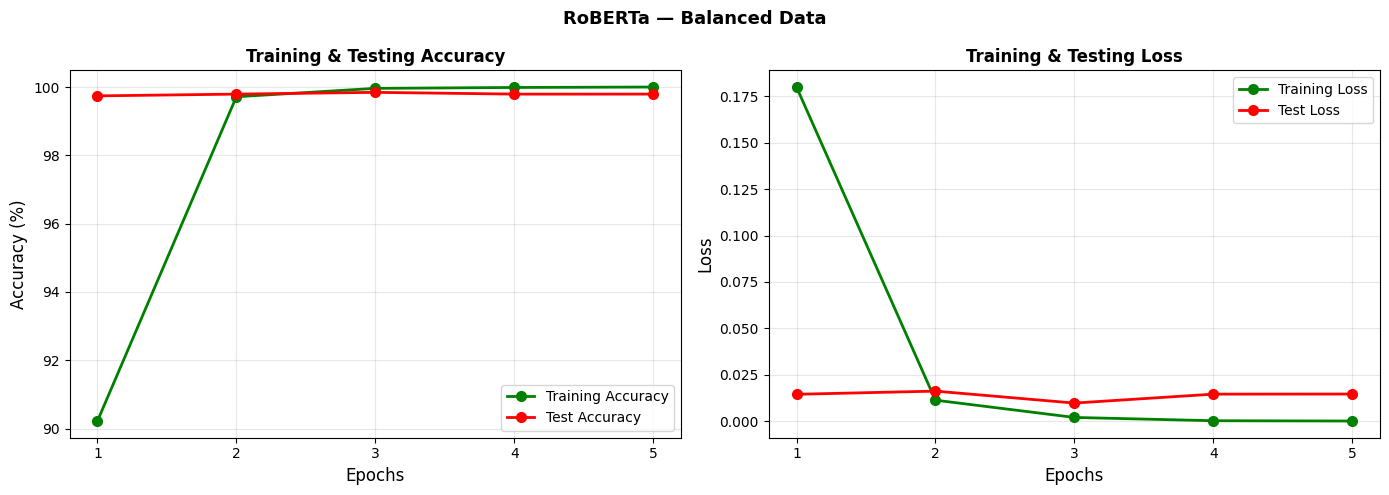

✅ Saved: /content/outputs/fig8b_roberta_balanced.png

  RoBERTa — Balanced
  Confusion Matrix:
                Pred ham   Pred spam
  Actual ham  :      961           4
  Actual spam :        0         965

  Overall Accuracy: 99.79%

  Class     Precision   Recall       F1
  --------------------------------------
  ham            1.00     1.00     1.00
  spam           1.00     1.00     1.00

⏭️ Tiếp tục Cell 13!


In [ ]:
# ⚠️ BẮT BUỘC: Xóa DistilBERT trước
del distilbert_bal_model
torch.cuda.empty_cache(); gc.collect()

free = (torch.cuda.get_device_properties(0).total_memory
        - torch.cuda.memory_allocated(0)) / 1e9
print(f"VRAM free: {free:.1f} GB  ← cần ≥ 10 GB")

roberta_bal_model, roberta_bal_tok, \
roberta_bal_hist, roberta_bal_preds, \
roberta_bal_labels = train_model(
    model_name      = 'roberta-base',
    tokenizer_class = RobertaTokenizer,
    model_class     = RobertaForSequenceClassification,
    X_train = X_train_bal, X_test = X_test_bal,
    y_train = y_train_bal, y_test = y_test_bal,
    dataset_type = 'Balanced'
)

plot_history(roberta_bal_hist, 'RoBERTa', 'Balanced',
             '/content/outputs/fig8b_roberta_balanced.png')

roberta_bal_cm, roberta_bal_acc = print_metrics(
    roberta_bal_preds, roberta_bal_labels,
    'RoBERTa', 'Balanced'
)
print("\n⏭️ Tiếp tục Cell 13!")

In [ ]:
# ⚠️ Thay các số dưới đây bằng kết quả THỰC TẾ từ Giai đoạn 1
# (copy từ file outputs/results_table.csv)
ml_imb = {
    'XGB': (99.84, 0.0095, 98.03, 0.0810),  # (train_acc, train_loss, test_acc, test_loss)
    'SVM': (99.62, 0.0077, 97.85, 0.0591),
    'KNN': (91.88, 0.1193, 91.21, 0.5429),
    'RF' : (100.0, 0.0199, 97.76, 0.1317),
}
ml_bal = {
    'XGB': (99.72, 0.0325, 98.34, 0.0621),
    'SVM': (99.86, 0.0041, 99.59, 0.0323),
    'KNN': (97.76, 0.0457, 94.97, 0.1371),
    'RF' : (100.0, 0.0167, 99.38, 0.0530),
}

def print_full_table(ml_res, hist_db, hist_rb, tag):
    print(f"\n{'='*72}")
    print(f"  TABLE — Comparative Performance ({tag})")
    print(f"{'='*72}")
    print(f"  {'Model':<14} {'Train Loss':>11} {'Train Acc':>10} {'Test Loss':>10} {'Test Acc':>10}")
    print(f"  {'-'*60}")
    for name, (ta, tl, tea, tel) in ml_res.items():
        print(f"  {name:<14} {tl:>11.4f} {ta:>9.2f}% {tel:>10.4f} {tea:>9.2f}%")
    print(f"  {'DistilBERT':<14} "
          f"{hist_db['train_loss'][-1]:>11.4f} "
          f"{hist_db['train_acc'][-1]:>9.2f}% "
          f"{hist_db['test_loss'][-1]:>10.4f} "
          f"{hist_db['test_acc'][-1]:>9.2f}%")
    print(f"  {'RoBERTa':<14} "
          f"{hist_rb['train_loss'][-1]:>11.4f} "
          f"{hist_rb['train_acc'][-1]:>9.2f}% "
          f"{hist_rb['test_loss'][-1]:>10.4f} "
          f"{hist_rb['test_acc'][-1]:>9.2f}%")
    print(f"{'='*72}")

print_full_table(ml_imb, distilbert_imb_hist, roberta_imb_hist, "Imbalanced")
print_full_table(ml_bal,  distilbert_bal_hist, roberta_bal_hist, "Balanced")
print("\n⏭️ Tiếp tục Cell 14!")


  TABLE — Comparative Performance (Imbalanced)
  Model           Train Loss  Train Acc  Test Loss   Test Acc
  ------------------------------------------------------------
  XGB                 0.0095     99.84%     0.0810     98.03%
  SVM                 0.0077     99.62%     0.0591     97.85%
  KNN                 0.1193     91.88%     0.5429     91.21%
  RF                  0.0199    100.00%     0.1317     97.76%
  DistilBERT          0.0039     99.87%     0.0466     98.65%
  RoBERTa             0.0002    100.00%     0.0495     99.37%

  TABLE — Comparative Performance (Balanced)
  Model           Train Loss  Train Acc  Test Loss   Test Acc
  ------------------------------------------------------------
  XGB                 0.0325     99.72%     0.0621     98.34%
  SVM                 0.0041     99.86%     0.0323     99.59%
  KNN                 0.0457     97.76%     0.1371     94.97%
  RF                  0.0167    100.00%     0.0530     99.38%
  DistilBERT          0.0004    100.

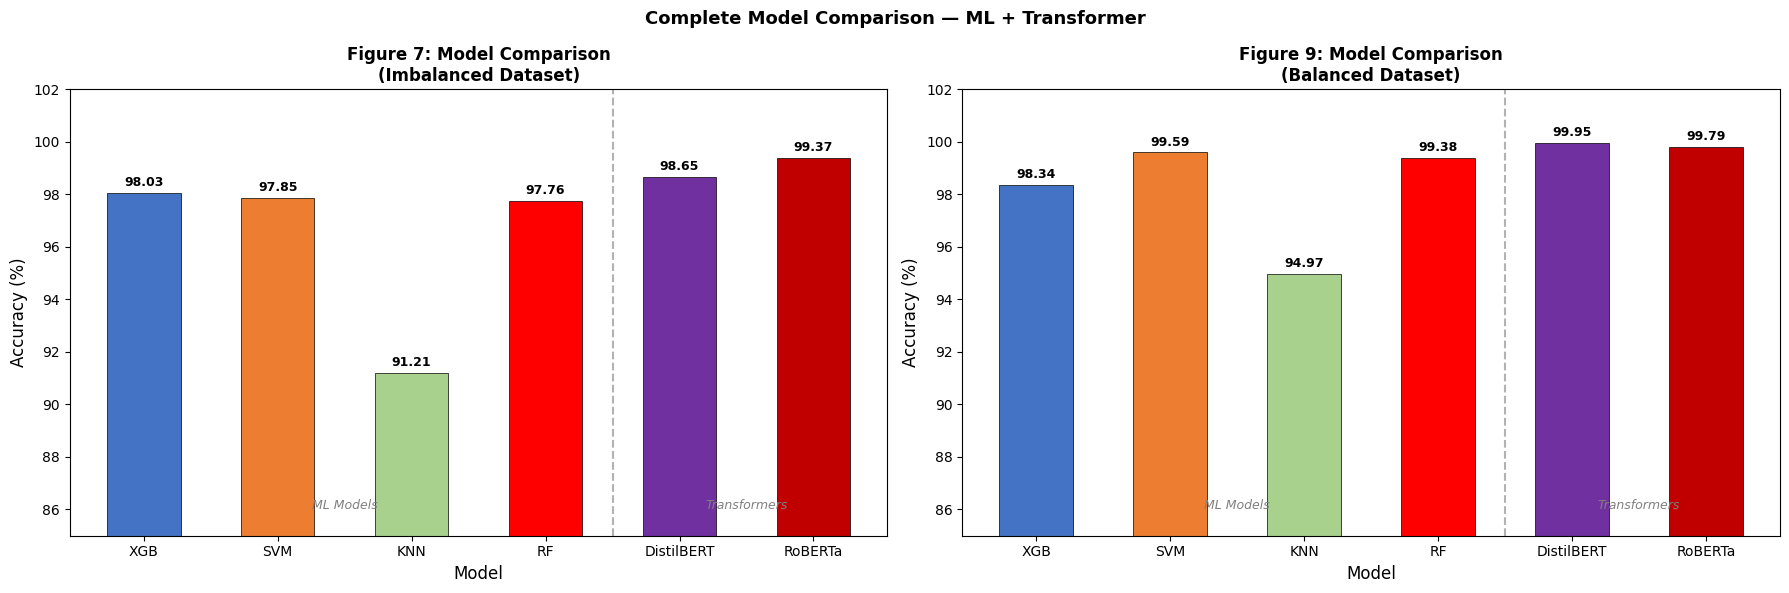

✅ Saved: /content/outputs/complete_comparison.png

⏭️ Tiếp tục Cell 15!


In [ ]:
# Lấy accuracy từ kết quả thực tế
all_models = ['XGB', 'SVM', 'KNN', 'RF', 'DistilBERT', 'RoBERTa']
colors     = ['#4472C4','#ED7D31','#A9D18E','#FF0000','#7030A0','#C00000']

accs_imb = [
    ml_imb['XGB'][2], ml_imb['SVM'][2],
    ml_imb['KNN'][2], ml_imb['RF'][2],
    distilbert_imb_hist['test_acc'][-1],
    roberta_imb_hist['test_acc'][-1]
]
accs_bal = [
    ml_bal['XGB'][2], ml_bal['SVM'][2],
    ml_bal['KNN'][2], ml_bal['RF'][2],
    distilbert_bal_hist['test_acc'][-1],
    roberta_bal_hist['test_acc'][-1]
]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, accs, title, fig_label in [
    (axes[0], accs_imb, 'Imbalanced Dataset', 'Figure 7'),
    (axes[1], accs_bal, 'Balanced Dataset',   'Figure 9')
]:
    bars = ax.bar(all_models, accs, color=colors,
                  width=0.55, edgecolor='black', linewidth=0.5)
    ax.set_ylim(85, 102)
    ax.set_ylabel('Accuracy (%)', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_title(f'{fig_label}: Model Comparison\n({title})',
                 fontsize=12, fontweight='bold')

    for bar, acc in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.15,
                f'{acc:.2f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold')

    # Đường phân cách ML vs Transformer
    ax.axvline(x=3.5, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.text(1.5, 86.0, 'ML Models',    ha='center', fontsize=9, color='gray', style='italic')
    ax.text(4.5, 86.0, 'Transformers', ha='center', fontsize=9, color='gray', style='italic')

plt.suptitle('Complete Model Comparison — ML + Transformer',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/outputs/complete_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: /content/outputs/complete_comparison.png")
print("\n⏭️ Tiếp tục Cell 15!")

In [ ]:
import shutil
from google.colab import files

# Zip outputs (biểu đồ)
shutil.make_archive('/content/Stage2_outputs', 'zip', '/content/outputs')
# Zip models (.pt files — cần cho Giai đoạn 3 XAI)
shutil.make_archive('/content/Stage2_models',  'zip', '/content/models')

print("📁 Các file trong outputs/:")
for f in sorted(os.listdir('/content/outputs')):
    size = os.path.getsize(f'/content/outputs/{f}')
    print(f"   {f}  ({size/1024:.0f} KB)")

print("\n📁 Các model đã lưu:")
for f in sorted(os.listdir('/content/models')):
    size = os.path.getsize(f'/content/models/{f}')
    print(f"   {f}  ({size/1024/1024:.0f} MB)")

# Download
files.download('/content/Stage2_outputs.zip')
files.download('/content/Stage2_models.zip')
print("\n✅ Download hoàn tất! Giai đoạn 2 XONG!")

📁 Các file trong outputs/:
   complete_comparison.png  (89 KB)
   fig6a_distilbert_imbalanced.png  (88 KB)
   fig6b_roberta_imbalanced.png  (96 KB)
   fig8a_distilbert_balanced.png  (98 KB)
   fig8b_roberta_balanced.png  (89 KB)

📁 Các model đã lưu:
   distilbert-base-uncased_Balanced.pt  (255 MB)
   distilbert-base-uncased_Imbalanced.pt  (255 MB)
   roberta-base_Balanced.pt  (476 MB)
   roberta-base_Imbalanced.pt  (476 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download hoàn tất! Giai đoạn 2 XONG!
